In [2]:
using System;
using System.Threading;

public class DefiniteIntegral
{
    public static double Solve(double a, double b, Func<double, double> function, double step, int threadsNumber)
    {
        if (function == null)
            throw new ArgumentNullException(nameof(function));

        if (threadsNumber <= 0)
            throw new ArgumentException("Неверное количество потоков");

        if (step <= 0)
            throw new ArgumentException("Шаг должен быть больше нуля");

        double result = 0;
        double partLength = (b - a) / threadsNumber;

        Barrier barrier = new Barrier(threadsNumber + 1);
        Thread[] threads = new Thread[threadsNumber];

        for (int i = 0; i < threadsNumber; i++)
        {
            double start = a + i * partLength;
            double end = start + partLength;

            threads[i] = new Thread(() =>
            {
                double sum = 0;
                double x = start;

                while (x + step <= end)
                {
                    sum += (function(x) + function(x + step)) * step / 2;
                    x += step;
                }

                if (x < end)
                {
                    sum += (function(x) + function(end)) * (end - x) / 2;
                }

                double oldValue;
                double newValue;

                do
                {
                    oldValue = result;
                    newValue = oldValue + sum;
                }
                while (Interlocked.CompareExchange(ref result, newValue, oldValue) != oldValue);

                barrier.SignalAndWait();
            });

            threads[i].Start();
        }

        barrier.SignalAndWait();

        return result;
    }

    public static double SolveSingleThread(double a, double b, Func<double, double> function, double step)
    {
        double sum = 0;
        long steps = (long)((b - a) / step);

        for (long k = 0; k < steps; k++)
        {
            double x1 = a + k * step;
            double x2 = a + (k + 1) * step;
            sum += (function(x1) + function(x2)) * step / 2;
        }

        return sum;
    }
}

In [1]:
#r "nuget:ScottPlot, 5.0.*"

The below script needs to be able to find the current output cell; this is an easy method to get it.

Installed Packages ScottPlot, 5.0.56

Loading extensions from `/Users/maksimlitvinov/.nuget/packages/skiasharp/2.88.9/interactive-extensions/dotnet/SkiaSharp.DotNet.Interactive.dll`

In [3]:
using Microsoft.DotNet.Interactive.Formatting;

Formatter.Register(typeof(ScottPlot.Plot), (p, w) => w.Write(((ScottPlot.Plot)p).GetPngHtml(400, 300)), HtmlFormatter.MimeType);

In [6]:
double[] steps = { 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6 };
double a = -100, b = 100;

Func<double, double> absSin = x => Math.Abs(Math.Sin(x));

double? prevResult = null;
double chosenStep = steps[0];

foreach (var step in steps)
{
    double result = DefiniteIntegral.Solve(a, b, absSin, step, threadsNumber: 4);

    if (prevResult.HasValue)
    {
        double diff = Math.Abs(result - prevResult.Value);
        Console.WriteLine($"Шаг = {step:E1}, результат = {result:F6}, |разница с предыдущим шагом| = {diff:E6}, сходимость достигнута: {diff < 1e-4}");
        if (diff < 1e-4)
        {
            chosenStep = step;
            break;
        }
    }
    else
    {
        Console.WriteLine($"Шаг = {step:E1}, результат = {result:F6} (базовое значение)");
    }

    prevResult = result;
}

Console.WriteLine($"\nВыбранный минимальный шаг (по критерию сходимости для |sin(x)|): {chosenStep:E1}");

Шаг = 1,0E-001, результат = 127,722100 (базовое значение)
Шаг = 1,0E-002, результат = 127,724619, |разница с предыдущим шагом| = 2,518755E-003, сходимость достигнута: False
Шаг = 1,0E-003, результат = 127,724638, |разница с предыдущим шагом| = 1,867561E-005, сходимость достигнута: True

Выбранный минимальный шаг (по критерию сходимости для |sin(x)|): 1,0E-003


In [7]:
using System.Diagnostics;

double optimalStep = 1e-3; // подставьте значение, которое нашли в ячейке 4
int[] threadCounts = { 1, 2, 4, 8, 16, 32, 64 };
int repeats = 5;

double[] threadCountsD = new double[threadCounts.Length];
double[] avgTimes = new double[threadCounts.Length];

for (int i = 0; i < threadCounts.Length; i++)
{
    int threads = threadCounts[i];
    double totalMs = 0;

    for (int r = 0; r < repeats; r++)
    {
        var sw = Stopwatch.StartNew();
        DefiniteIntegral.Solve(a, b, Math.Sin, optimalStep, threads);
        sw.Stop();
        totalMs += sw.Elapsed.TotalMilliseconds;
    }

    double avg = totalMs / repeats;
    threadCountsD[i] = threads;
    avgTimes[i] = avg;

    Console.WriteLine($"Потоков: {threads}, среднее время: {avg:F2} мс");
}

Потоков: 1, среднее время: 3,98 мс
Потоков: 2, среднее время: 1,79 мс
Потоков: 4, среднее время: 2,11 мс
Потоков: 8, среднее время: 1,65 мс
Потоков: 16, среднее время: 1,53 мс
Потоков: 32, среднее время: 2,62 мс
Потоков: 64, среднее время: 4,77 мс



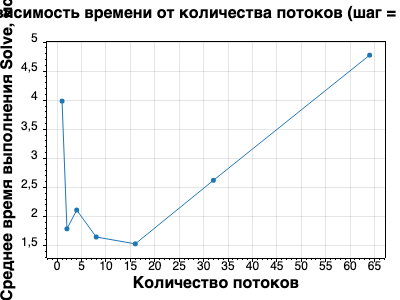

In [8]:
ScottPlot.Plot plt = new();
plt.Add.Scatter(threadCountsD, avgTimes);

plt.XLabel("Количество потоков");
plt.YLabel("Среднее время выполнения Solve, мс");
plt.Title($"Зависимость времени от количества потоков (шаг = {optimalStep:E0})");

plt

In [9]:
int bestThreads = 16; // подставьте найденное оптимальное число потоков из ячейки 5

double totalMultiMs = 0, totalSingleMs = 0;

for (int r = 0; r < repeats; r++)
{
    var sw1 = Stopwatch.StartNew();
    DefiniteIntegral.Solve(a, b, Math.Sin, optimalStep, bestThreads);
    sw1.Stop();
    totalMultiMs += sw1.Elapsed.TotalMilliseconds;

    var sw2 = Stopwatch.StartNew();
    DefiniteIntegral.SolveSingleThread(a, b, Math.Sin, optimalStep);
    sw2.Stop();
    totalSingleMs += sw2.Elapsed.TotalMilliseconds;
}

double avgMulti = totalMultiMs / repeats;
double avgSingle = totalSingleMs / repeats;
double speedupPercent = (avgSingle - avgMulti) / avgSingle * 100;

Console.WriteLine($"Однопоточная версия: {avgSingle:F2} мс");
Console.WriteLine($"Многопоточная версия ({bestThreads} потоков): {avgMulti:F2} мс");
Console.WriteLine($"Ускорение: {speedupPercent:F1}%");

Однопоточная версия: 2,53 мс
Многопоточная версия (16 потоков): 1,45 мс
Ускорение: 42,7%


In [14]:
using System.IO;
string report = $@"Результаты исследования эффективности многопоточных вычислений
================================================================

Функция: sin(x), отрезок интегрирования: [-100, 100]

Шаг интегрирования: 1E-3
(минимальный шаг из диапазона {{1e-1..1e-6}}, при котором разница результатов между 
соседними шагами дискретизации становится меньше 1e-4. Поскольку sin(x) — нечётная 
функция на симметричном относительно нуля отрезке, аналитический интеграл тождественно 
равен нулю при любом шаге, что делает прямое сравнение с аналитикой неинформативным. 
Поэтому шаг определялся по критерию сходимости результатов для |sin(x)| — функции, 
интеграл которой не вырождается в ноль и позволяет корректно оценить точность метода 
трапеций. Найденный шаг затем применён к исходной функции sin(x).)

Оптимальное количество потоков: 16
(число потоков, на котором функция Solve показала минимальное среднее время выполнения 
среди проверенных вариантов {{1, 2, 4, 8, 16, 32, 64}}. При дальнейшем увеличении числа 
потоков (32, 64) время начинает расти из-за накладных расходов на создание потоков 
и синхронизацию, превышающих число доступных ядер процессора.)

Время выполнения однопоточной версии: 2,53 мс
(среднее по 5 замерам, реализация без использования Thread/Task — обычный 
последовательный цикл вычисления методом трапеций)

Время выполнения многопоточной версии: 1,45 мс
(среднее по 5 замерам, 16 потоков, шаг 1e-3)

Ускорение многопоточной версии относительно однопоточной: 42,7%
(рассчитано как (однопоточное время - многопоточное время) / однопоточное время * 100%.
Критерий задания — ускорение не менее 15% — выполнен с запасом.)
";

File.WriteAllText("results.txt", report);
Console.WriteLine("Отчёт сохранён в results.txt");

Отчёт сохранён в results.txt
